# POS Tags as Features for BERT-based NER

This notebook analyzes the saved JSON results from the project experiments.

The goal is to turn the raw experiment outputs into readable tables, poster-ready figures, and a few additional diagnostic views. We will compare the BERT NER baseline with POS-aware variants, inspect POS tagging errors, and analyze whether POS errors propagate into NER predictions.

## Setup

The next cell imports the libraries used in the notebook and defines repository paths. The code works both when the notebook is run from the repository root and when it is run from the `notebooks/` directory.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if Path("results").exists():
    ROOT = Path(".").resolve()
else:
    ROOT = Path("..").resolve()

RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

METRICS_DIR = RESULTS_DIR / "metrics"
POS_DIR = RESULTS_DIR / "pos"
CORRUPTION_DIR = RESULTS_DIR / "pos_corruption"

print("Repository root:", ROOT)
print("Results directory:", RESULTS_DIR)
print("Figures directory:", FIGURES_DIR)

Repository root: /Users/chrnegor/Documents/study/nlp-case-study
Results directory: /Users/chrnegor/Documents/study/nlp-case-study/results
Figures directory: /Users/chrnegor/Documents/study/nlp-case-study/figures


## Helper functions

The JSON files do not all have exactly the same structure. Some files store one test metric dictionary, while others store mean and standard deviation over multiple random seeds. The helper functions below normalize these formats into simple Python dictionaries and tables.

In [2]:
def load_json(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def metric_value(payload, metric_name: str):
    if "test" in payload and metric_name in payload["test"]:
        return payload["test"][metric_name]

    if "test_summary" in payload:
        summary = payload["test_summary"]

        if metric_name in summary:
            value = summary[metric_name]
            return value["mean"] if isinstance(value, dict) and "mean" in value else value

        prefixed = f"test_{metric_name}"
        if prefixed in summary:
            value = summary[prefixed]
            return value["mean"] if isinstance(value, dict) and "mean" in value else value

    if metric_name in payload:
        return payload[metric_name]

    return None


def metric_std(payload, metric_name: str):
    if "test_summary" not in payload:
        return None

    summary = payload["test_summary"]
    for key in [metric_name, f"test_{metric_name}"]:
        if key in summary and isinstance(summary[key], dict):
            return summary[key].get("std")

    return None


def format_mean_std(mean, std=None, decimals=4):
    if mean is None:
        return "—"
    if std is None:
        return f"{mean:.{decimals}f}"
    return f"{mean:.{decimals}f} ± {std:.{decimals}f}"


def extract_test_row(name: str, payload: dict):
    row = {"Model": name}
    for metric in ["precision", "recall", "f1", "accuracy", "macro_f1"]:
        row[metric] = metric_value(payload, metric)
        row[f"{metric}_std"] = metric_std(payload, metric)
    return row


def save_current_figure(filename: str):
    path = FIGURES_DIR / filename
    plt.savefig(path, dpi=220, bbox_inches="tight")
    print(f"Saved figure to: {path}")

## Load experiment results

This cell loads all JSON files that are expected to exist in the `results/` folder. The variables are kept explicit so that each later section can refer to the exact experiment it needs.

In [3]:
paths = {
    "baseline": METRICS_DIR / "ner_baseline.json",
    "gold_pos": METRICS_DIR / "ner_gold_pos.json",
    "predicted_pos": METRICS_DIR / "ner_predicted_pos.json",
    "early_fusion_metrics": METRICS_DIR / "early_fusion_metrics.json",
    "late_fusion_metrics": METRICS_DIR / "late_fusion_metrics.json",
    "pos_confusion": POS_DIR / "confusion_matrix.json",
    "early_corruption": CORRUPTION_DIR / "early_fusion.json",
    "late_corruption": CORRUPTION_DIR / "late_fusion.json",
}

for name, path in paths.items():
    print(f"{name:24s}", "OK" if path.exists() else f"MISSING: {path}")

baseline = load_json(paths["baseline"])
gold_pos = load_json(paths["gold_pos"])
predicted_pos = load_json(paths["predicted_pos"])
early_fusion_metrics = load_json(paths["early_fusion_metrics"])
late_fusion_metrics = load_json(paths["late_fusion_metrics"])
pos_confusion = load_json(paths["pos_confusion"])
early_corruption = load_json(paths["early_corruption"])
late_corruption = load_json(paths["late_corruption"])

baseline                 OK
gold_pos                 OK
predicted_pos            OK
early_fusion_metrics     OK
late_fusion_metrics      OK
pos_confusion            OK
early_corruption         OK
late_corruption          OK


## Main NER results

The next table compares the BERT NER baseline with the main POS-aware models. When a result was run with multiple random seeds, the table reports mean and standard deviation.

In [4]:
main_rows = [
    extract_test_row("BERT NER baseline", baseline),
    extract_test_row("NER + Gold POS", gold_pos),
    extract_test_row("NER + Predicted POS", predicted_pos),
]

main_df_raw = pd.DataFrame(main_rows)

main_df = pd.DataFrame({
    "Model": main_df_raw["Model"],
    "Precision": [format_mean_std(row["precision"], row["precision_std"]) for _, row in main_df_raw.iterrows()],
    "Recall": [format_mean_std(row["recall"], row["recall_std"]) for _, row in main_df_raw.iterrows()],
    "F1": [format_mean_std(row["f1"], row["f1_std"]) for _, row in main_df_raw.iterrows()],
    "Accuracy": [format_mean_std(row["accuracy"], row["accuracy_std"]) for _, row in main_df_raw.iterrows()],
    "Macro F1": [format_mean_std(row["macro_f1"], row["macro_f1_std"]) for _, row in main_df_raw.iterrows()],
})

main_df

,Model,Precision,Recall,F1,Accuracy,Macro F1
0,BERT NER baseline,0.9070 ± 0.0035,0.9101 ± 0.0008,0.9085 ± 0.0017,0.9803 ± 0.0002,0.8801 ± 0.0004
1,NER + Gold POS,0.9047 ± 0.0011,0.9105 ± 0.0003,0.9076 ± 0.0005,0.9799 ± 0.0001,0.8787 ± 0.0018
2,NER + Predicted POS,0.9050 ± 0.0040,0.9105 ± 0.0019,0.9077 ± 0.0029,0.9800 ± 0.0004,0.8792 ± 0.0009


## Main results chart

The next figure visualizes the main test F1 and macro F1 scores. This gives a compact view of whether POS-aware variants improve over the baseline.

Saved figure to: /Users/chrnegor/Documents/study/nlp-case-study/figures/main_ner_results.png


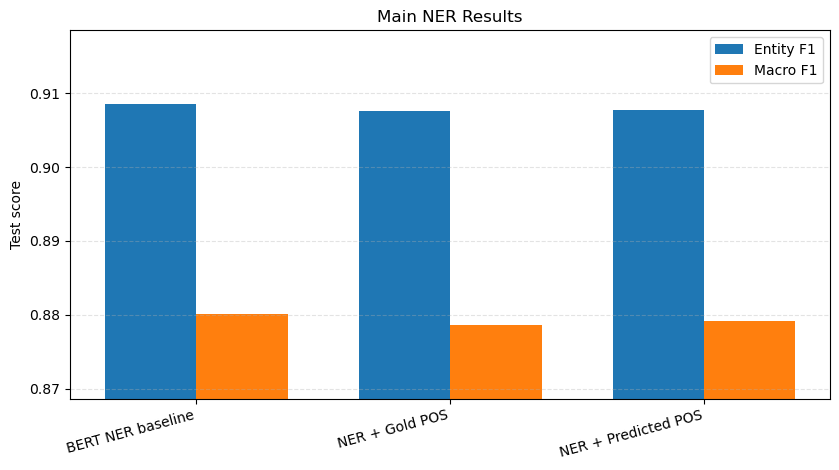

In [5]:
plot_df = main_df_raw.copy()

x = np.arange(len(plot_df))
width = 0.36

plt.figure(figsize=(8.5, 4.8))
plt.bar(x - width / 2, plot_df["f1"], width, label="Entity F1")
plt.bar(x + width / 2, plot_df["macro_f1"], width, label="Macro F1")

plt.xticks(x, plot_df["Model"], rotation=15, ha="right")
plt.ylabel("Test score")
plt.title("Main NER Results")
plt.ylim(
    min(plot_df["macro_f1"].min(), plot_df["f1"].min()) - 0.01,
    max(plot_df["macro_f1"].max(), plot_df["f1"].max()) + 0.01,
)
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend()
plt.tight_layout()

save_current_figure("main_ner_results.png")
plt.show()

## POS Tagger Error Analysis

The POS confusion file does not store the full confusion matrix directly. Instead, it contains a summary of the most frequent POS tagging mistakes.  
Here we visualize the largest POS confusions to understand what kind of POS noise is later used in the controlled corruption experiment.

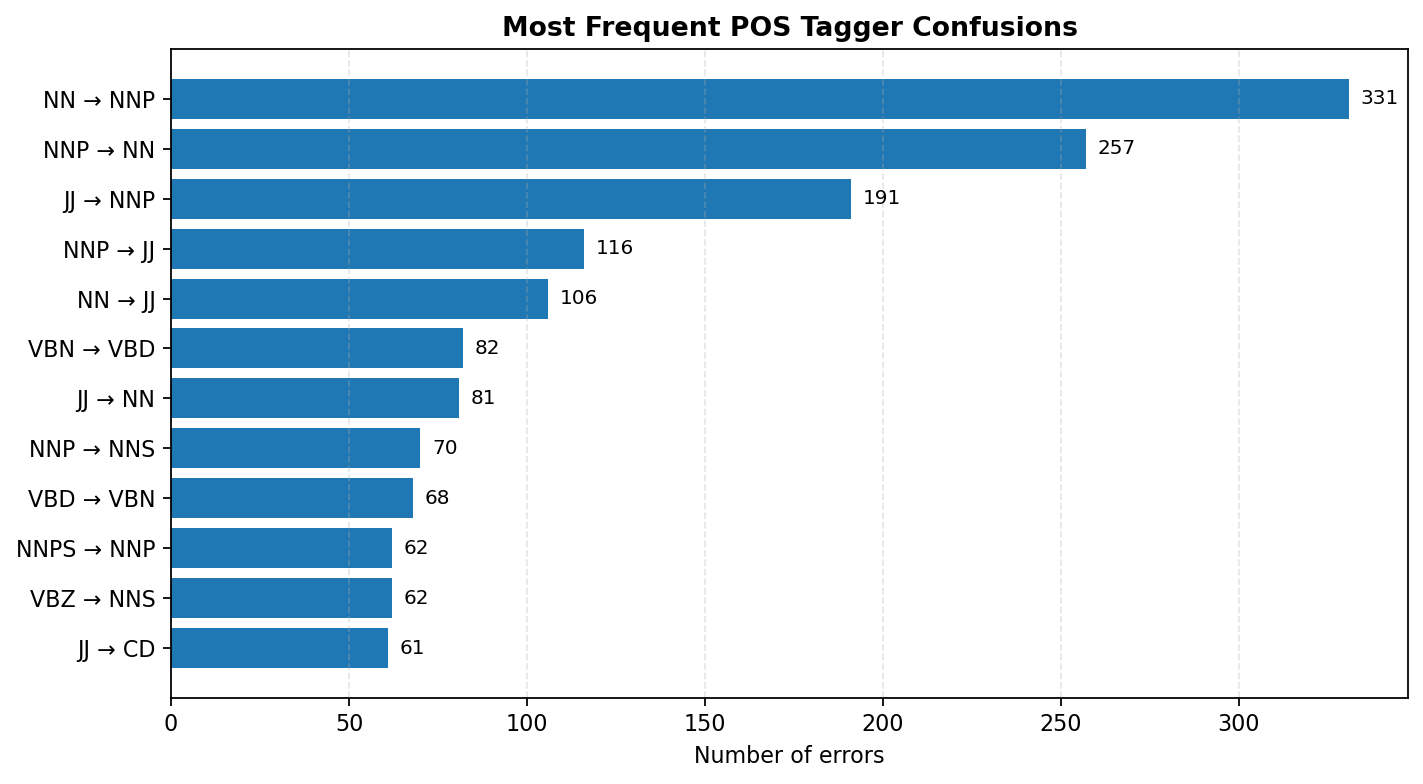

Saved figure to: /Users/chrnegor/Documents/study/nlp-case-study/figures/top_pos_confusions.png


In [8]:
pos_confusion = load_json(RESULTS_DIR / "pos" / "confusion_matrix.json")

top_confusions = pos_confusion.get("top_confusions", [])

POS_ID_TO_NAME = {
    0: '"', 1: "''", 2: "#", 3: "$", 4: "(", 5: ")", 6: ",", 7: ".",
    8: ":", 9: "``", 10: "CC", 11: "CD", 12: "DT", 13: "EX",
    14: "FW", 15: "IN", 16: "JJ", 17: "JJR", 18: "JJS", 19: "LS",
    20: "MD", 21: "NN", 22: "NNP", 23: "NNPS", 24: "NNS",
    25: "NN|SYM", 26: "PDT", 27: "POS", 28: "PRP", 29: "PRP$",
    30: "RB", 31: "RBR", 32: "RBS", 33: "RP", 34: "SYM", 35: "TO",
    36: "UH", 37: "VB", 38: "VBD", 39: "VBG", 40: "VBN",
    41: "VBP", 42: "VBZ", 43: "WDT", 44: "WP", 45: "WP$", 46: "WRB",
}

def pos_label_to_name(label):
    raw_id = int(label.replace("POS_", ""))
    return POS_ID_TO_NAME.get(raw_id, label)

if not top_confusions:
    print("No top_confusions found.")
    print("Available keys:", list(pos_confusion.keys()))
else:
    top_n = 12
    rows = top_confusions[:top_n]

    labels = [
        f"{pos_label_to_name(row['gold_label'])} → {pos_label_to_name(row['pred_label'])}"
        for row in rows
    ]
    counts = [row["count"] for row in rows]

    fig, ax = plt.subplots(figsize=(9, 5), dpi=160)

    y_pos = np.arange(len(labels))
    ax.barh(y_pos, counts)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()

    ax.set_xlabel("Number of errors")
    ax.set_title("Most Frequent POS Tagger Confusions", fontweight="bold")

    for i, count in enumerate(counts):
        ax.text(
            count + max(counts) * 0.01,
            i,
            str(count),
            va="center",
            fontsize=9,
        )

    ax.grid(axis="x", linestyle="--", alpha=0.3)

    plt.tight_layout()

    save_path = FIGURES_DIR / "top_pos_confusions.png"
    plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.show()

    print(f"Saved figure to: {save_path}")

## POS Tagger Performance

Before using predicted POS tags as NER features, we evaluate the POS tagger itself.  
We report token-level accuracy, weighted F1, and macro F1 on the validation and test splits. Macro F1 is lower than weighted F1 because rare POS tags are harder to predict.

In [9]:
pos_summary = load_json(RESULTS_DIR / "pos" / "confusion_matrix.json")

val_pos = pos_summary["validation_metrics"]
test_pos = pos_summary["test_metrics"]

pos_perf_df = pd.DataFrame(
    [
        {
            "Split": "Validation",
            "Accuracy": val_pos["validation_accuracy"],
            "Weighted F1": val_pos["validation_f1_weighted"],
            "Macro F1": val_pos["validation_f1_macro"],
            "Loss": val_pos["validation_loss"],
        },
        {
            "Split": "Test",
            "Accuracy": test_pos["test_accuracy"],
            "Weighted F1": test_pos["test_f1_weighted"],
            "Macro F1": test_pos["test_f1_macro"],
            "Loss": test_pos["test_loss"],
        },
    ]
)

display(
    pos_perf_df.style.format(
        {
            "Accuracy": "{:.4f}",
            "Weighted F1": "{:.4f}",
            "Macro F1": "{:.4f}",
            "Loss": "{:.4f}",
        }
    )
)

,Split,Accuracy,Weighted F1,Macro F1,Loss
0,Validation,0.9471,0.9467,0.8286,0.2124
1,Test,0.9415,0.9407,0.8529,0.2600


## Injection strategy comparison

The next table compares the POS injection strategies used in the project. This analysis is useful for understanding whether the position of POS injection changes NER quality.

In [10]:
strategy_rows = [
    extract_test_row("Encoder-independent fusion", gold_pos),
    extract_test_row("Early encoder fusion", early_fusion_metrics),
    extract_test_row("Late encoder fusion", late_fusion_metrics),
]

strategy_raw = pd.DataFrame(strategy_rows)

strategy_df = pd.DataFrame({
    "Fusion strategy": strategy_raw["Model"],
    "Test Accuracy": [format_mean_std(v, None) for v in strategy_raw["accuracy"]],
    "Test Macro F1": [format_mean_std(v, None) for v in strategy_raw["macro_f1"]],
    "Test F1": [format_mean_std(v, None) for v in strategy_raw["f1"]],
})

strategy_df

,Fusion strategy,Test Accuracy,Test Macro F1,Test F1
0,Encoder-independent fusion,0.9799,0.8787,0.9076
1,Early encoder fusion,0.9658,0.8147,0.8386
2,Late encoder fusion,0.9801,0.8776,0.9075


Saved figure to: /Users/chrnegor/Documents/study/nlp-case-study/figures/pos_injection_strategy_comparison.png


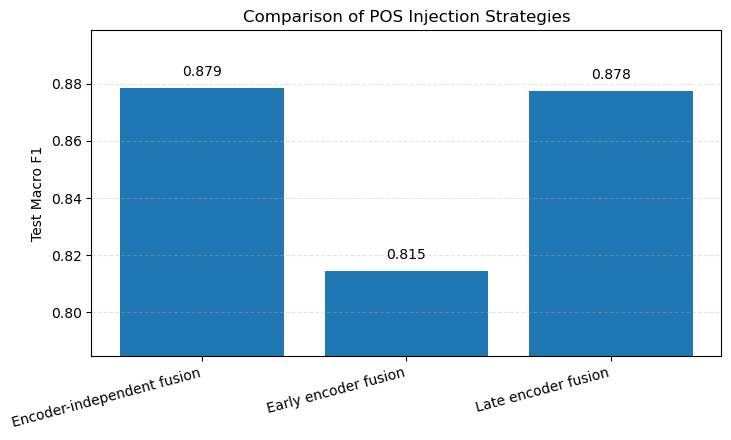

In [11]:
plt.figure(figsize=(7.5, 4.5))

x = np.arange(len(strategy_raw))
plt.bar(x, strategy_raw["macro_f1"])

plt.xticks(x, strategy_raw["Model"], rotation=15, ha="right")
plt.ylabel("Test Macro F1")
plt.title("Comparison of POS Injection Strategies")
plt.ylim(strategy_raw["macro_f1"].min() - 0.03, strategy_raw["macro_f1"].max() + 0.02)
plt.grid(axis="y", linestyle="--", alpha=0.35)

for idx, value in enumerate(strategy_raw["macro_f1"]):
    plt.text(idx, value + 0.003, f"{value:.3f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
save_current_figure("pos_injection_strategy_comparison.png")
plt.show()

## Controlled POS corruption

The controlled corruption experiment tests whether POS errors propagate into NER predictions. Gold POS tags are corrupted at different rates, and replacement tags are sampled from the POS tagger confusion matrix.

In [12]:
def corruption_to_df(data, label):
    df = pd.DataFrame(data)
    df["fusion"] = label
    return df


early_corr_df = corruption_to_df(early_corruption, "Encoder-independent fusion")
late_corr_df = corruption_to_df(late_corruption, "Late encoder fusion")

corruption_df = pd.concat([early_corr_df, late_corr_df], ignore_index=True)
corruption_df[["fusion", "corruption_rate", "actual_changed_fraction", "f1", "macro_f1", "accuracy"]].head()

,fusion,corruption_rate,actual_changed_fraction,f1,macro_f1,accuracy
0,Encoder-independent fusion,0.00,0.000000,0.906485,0.876815,0.979864
1,Encoder-independent fusion,0.05,0.049467,0.906405,0.876781,0.979843
2,Encoder-independent fusion,0.10,0.098676,0.906485,0.876815,0.979864
3,Encoder-independent fusion,0.20,0.199311,0.906485,0.876815,0.979864
4,Encoder-independent fusion,0.30,0.299666,0.906662,0.876933,0.979886


Saved figure to: /Users/chrnegor/Documents/study/nlp-case-study/figures/controlled_pos_corruption_curve.png


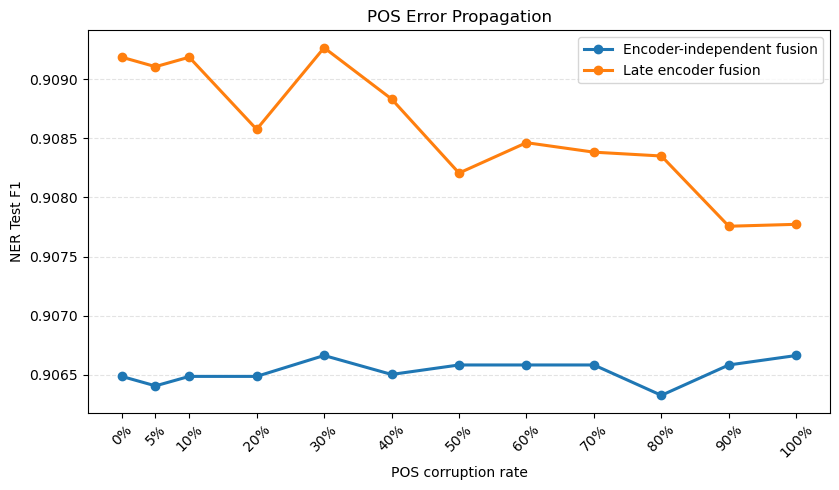

In [13]:
plt.figure(figsize=(8.5, 5.0))

for fusion_name, group in corruption_df.groupby("fusion"):
    group = group.sort_values("corruption_rate")
    plt.plot(
        group["corruption_rate"],
        group["f1"],
        marker="o",
        linewidth=2.2,
        label=fusion_name,
    )

plt.title("POS Error Propagation")
plt.xlabel("POS corruption rate")
plt.ylabel("NER Test F1")
plt.xticks(
    sorted(corruption_df["corruption_rate"].unique()),
    [f"{int(x * 100)}%" for x in sorted(corruption_df["corruption_rate"].unique())],
    rotation=45,
)
plt.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend()
plt.tight_layout()

save_current_figure("controlled_pos_corruption_curve.png")
plt.show()

## Corruption robustness summary

The next table computes the total F1 drop between the clean POS setting and the highest corruption rate. This summarizes how sensitive each model is to POS noise.

In [14]:
drop_rows = []

for fusion_name, group in corruption_df.groupby("fusion"):
    group = group.sort_values("corruption_rate")
    clean = group.iloc[0]
    corrupted = group.iloc[-1]

    drop_rows.append({
        "Fusion": fusion_name,
        "Clean F1": clean["f1"],
        "Max corruption F1": corrupted["f1"],
        "F1 drop": clean["f1"] - corrupted["f1"],
        "Clean Macro F1": clean["macro_f1"],
        "Max corruption Macro F1": corrupted["macro_f1"],
        "Macro F1 drop": clean["macro_f1"] - corrupted["macro_f1"],
    })

drop_df = pd.DataFrame(drop_rows)
drop_df

,Fusion,Clean F1,Max corruption F1,F1 drop,Clean Macro F1,Max corruption Macro F1,Macro F1 drop
0,Encoder-independent fusion,0.906485,0.906662,-0.000177,0.876815,0.876933,-0.000118
1,Late encoder fusion,0.909187,0.907773,0.001415,0.878958,0.877395,0.001562


## Result deltas from the baseline

The next table compares POS-aware models against the baseline. This makes it easier to see whether each POS variant improves or degrades NER performance.

In [17]:
baseline_f1 = metric_value(baseline, "f1")
baseline_macro_f1 = metric_value(baseline, "macro_f1")

delta_rows = []
for name, payload in [
    ("NER + Gold POS", gold_pos),
    ("NER + Predicted POS", predicted_pos),
    ("Early encoder fusion", early_fusion_metrics),
    ("Late encoder fusion", late_fusion_metrics),
]:
    f1 = metric_value(payload, "f1")
    macro_f1 = metric_value(payload, "macro_f1")

    delta_rows.append({
        "Model": name,
        "F1": f1,
        "Δ F1 vs baseline": None if f1 is None else f1 - baseline_f1,
        "Macro F1": macro_f1,
        "Δ Macro F1 vs baseline": None if macro_f1 is None else macro_f1 - baseline_macro_f1,
    })

delta_df = pd.DataFrame(delta_rows)
delta_df

,Model,F1,Δ F1 vs baseline,Macro F1,Δ Macro F1 vs baseline
0,NER + Gold POS,0.907551,-0.000953,0.878656,-0.001438
1,NER + Predicted POS,0.907713,-0.000791,0.879152,-0.000942
2,Early encoder fusion,0.838596,-0.069907,0.814660,-0.065434
3,Late encoder fusion,0.907495,-0.001009,0.877589,-0.002506


## Takeaways

Explicit POS features do not provide a consistent improvement over the BERT-based NER baseline. Predicted POS performs similarly to gold POS, and controlled corruption shows that POS errors have weak propagation into NER predictions.

In this setup, BERT representations already capture most of the useful syntactic signal for CoNLL-2003 NER.